Visualization - Matplotlib

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
plt.rcParams['font.family'] = 'Malgun Gothic'  #한글 font 사용
plt.rcParams['axes.unicode_minus'] = False

In [4]:
data = {

    "order_date": [

        "2026-09-01", "2026-09-01", "2026-09-02", "2026-09-02",

        "2026-09-03", "2026-09-03", "2026-09-04", "2026-09-04",

        "2026-09-05", "2026-09-05"

    ],

    "customer": ["홍길동", "김철수", "이영희", "홍길동", "박민수", "김철수", "최지훈", "이영희", "홍길동", "박민수"],

    "category": ["주변기기", "주변기기", "컴퓨터", "저장장치", "주변기기", "저장장치", "컴퓨터", "주변기기", "저장장치", "컴퓨터"],

    "product": ["키보드", "마우스", "노트북", "USB", "마우스", "USB", "노트북", "키보드", "SSD", "모니터"],

    "quantity": [2, 1, 1, 5, 3, 4, 1, 2, 1, 1],

    "unit_price": [30000, 15000, 1200000, 12000, 15000, 12000, 1200000, 30000, 90000, 250000]

}

In [6]:
df = pd.DataFrame(data)
df

,order_date,customer,category,product,quantity,unit_price
0,2026-09-01,홍길동,주변기기,키보드,2,30000
1,2026-09-01,김철수,주변기기,마우스,1,15000
2,2026-09-02,이영희,컴퓨터,노트북,1,1200000
3,2026-09-02,홍길동,저장장치,USB,5,12000
4,2026-09-03,박민수,주변기기,마우스,3,15000
5,2026-09-03,김철수,저장장치,USB,4,12000
6,2026-09-04,최지훈,컴퓨터,노트북,1,1200000
7,2026-09-04,이영희,주변기기,키보드,2,30000
8,2026-09-05,홍길동,저장장치,SSD,1,90000
9,2026-09-05,박민수,컴퓨터,모니터,1,250000


In [7]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['total_price'] = df['quantity'] * df['unit_price']
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   order_date   10 non-null     datetime64[us]
 1   customer     10 non-null     str           
 2   category     10 non-null     str           
 3   product      10 non-null     str           
 4   quantity     10 non-null     int64         
 5   unit_price   10 non-null     int64         
 6   total_price  10 non-null     int64         
dtypes: datetime64[us](1), int64(3), str(3)
memory usage: 692.0 bytes


Remove missing data and Outlier 

In [ ]:
df['category'].unique()

# works for other categories

<StringArray>
['주변기기', '컴퓨터', '저장장치']
Length: 3, dtype: str

In [14]:
df['category'].value_counts()

category
주변기기    4
컴퓨터     3
저장장치    3
Name: count, dtype: int64

Matplotlib manual

1. Line graph

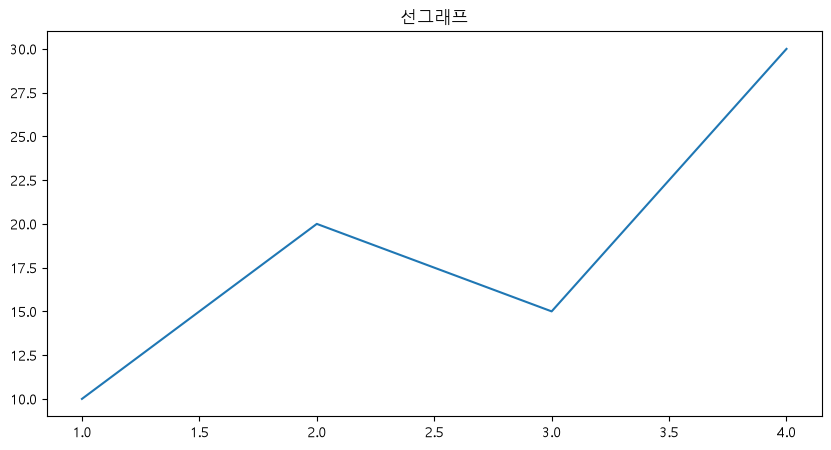

In [16]:
plt.figure(figsize=(10, 5))  # figsize=(graph width, height)
plt.plot([1,2,3,4], [10,20,15,30])
plt.title('선그래프')
plt.show()

Seaborn 

In [17]:
sns.set_theme(style='darkgrid', font='Malgun Gothic')

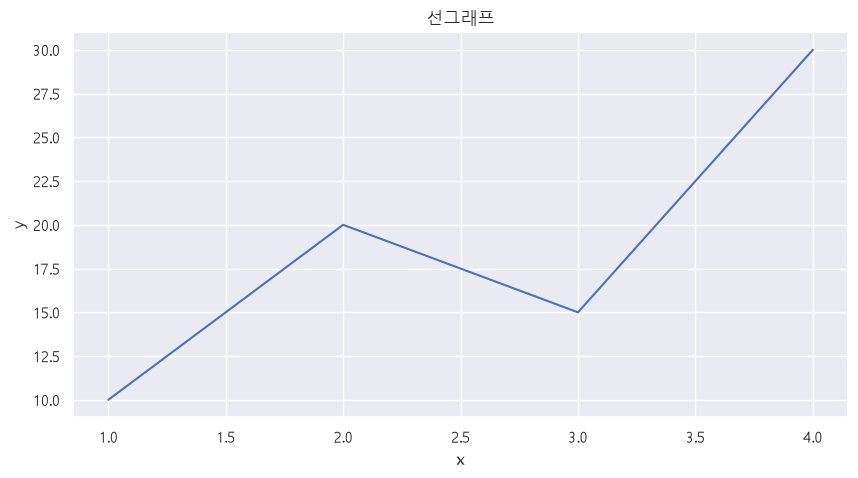

In [18]:
plt.figure(figsize=(10, 5))  # figsize=(graph width, height)
plt.plot([1,2,3,4], [10,20,15,30])
plt.title('선그래프')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

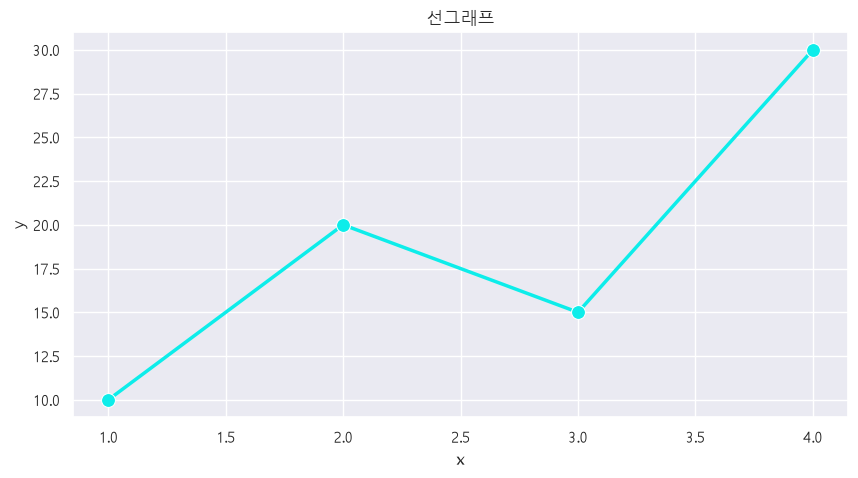

In [23]:
plt.figure(figsize=(10, 5))  # figsize=(graph width, height)
# plt.plot([1,2,3,4], [10,20,15,30])

sns.lineplot(
    x=[1,2,3,4],
    y=[10,20,15,30],
    marker= 'o',
    markersize=10,
    linewidth=2.5,
    color= "#0DEDEA"  #RGB
)

plt.title('선그래프')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

Bar graph

In [27]:
df.groupby('category')['total_price'].sum().reset_index()

,category,total_price
0,저장장치,198000
1,주변기기,180000
2,컴퓨터,2650000


In [28]:
cate_sales= df.groupby('category')['total_price'].sum().reset_index()

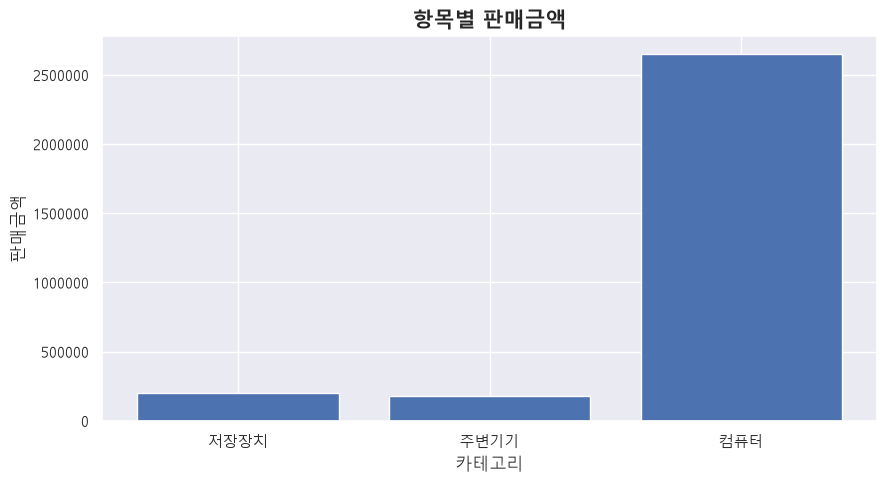

In [ ]:
plt.figure(figsize=(10, 5))

# 막대그래프
plt.bar(x=cate_sales['category'], height=cate_sales['total_price'])
plt.title('항목별 판매금액', fontsize=15, fontweight='bold')
plt.xlabel('카테고리')
plt.ylabel('판매금액')

plt.ticklabel_format(style='plain', axis='y') 
plt.show()

Line graph

In [36]:
df.groupby('order_date')['total_price'].sum().reset_index()

,order_date,total_price
0,2026-09-01,75000
1,2026-09-02,1260000
2,2026-09-03,93000
3,2026-09-04,1260000
4,2026-09-05,340000


In [ ]:
daily_sales = df.groupby('order_date')['total_price'].sum().reset_index()


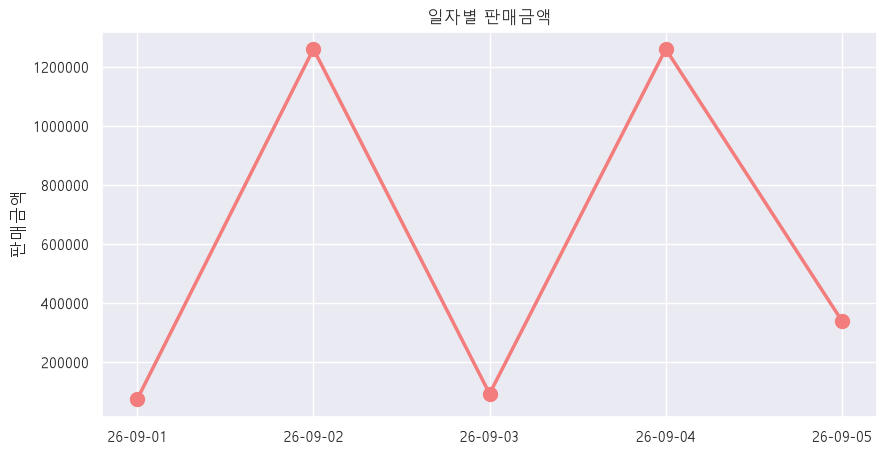

In [72]:
plt.figure(figsize=(10,5))
plt.plot(daily_sales['order_date'], daily_sales['total_price'], 
         marker='o', 
         markersize=10, 
         linewidth=2.5, 
         color= "#F37C7C")

plt.title('일자별 판매금액')
plt.ylabel('판매금액')
plt.ticklabel_format(style='plain', axis='y')

#실제 데이터가 있는 위치의 x좌표 레이블 표시
plt.xticks(
    daily_sales['order_date'],
    daily_sales['order_date'].dt.strftime('%y-%m-%d')
)

plt.show()

Histogram: std, distribution

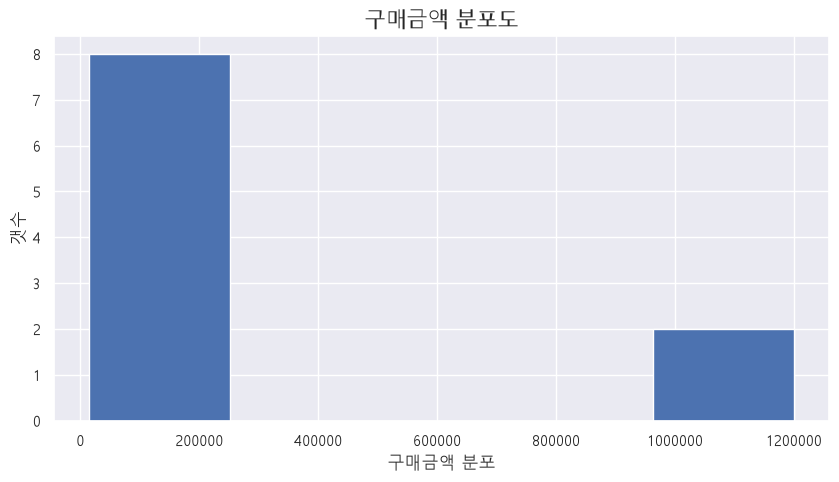

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(df['total_price'], bins=5) # bins 구간개수
plt.title('구매금액 분포도', fontsize=15)
plt.xlabel('구매금액 분포')
plt.ylabel('갯수')

plt.ticklabel_format(style='plain', axis='x')
plt.show()

Scatter Plot

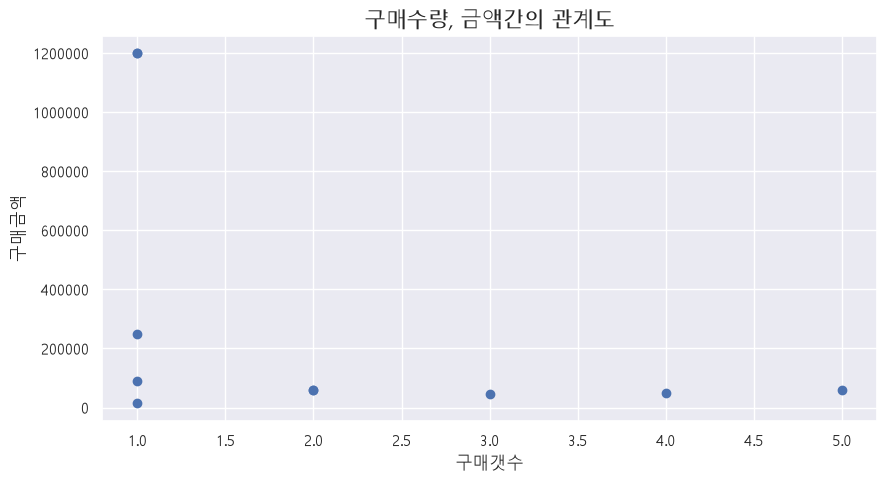

In [47]:
plt.figure(figsize=(10, 5))

plt.scatter(x=df['quantity'], y=df['total_price'])
plt.title('구매수량, 금액간의 관계도', fontsize=15)
plt.xlabel('구매갯수')
plt.ylabel('구매금액')

plt.ticklabel_format(style='plain', axis='y')
plt.show()

Box Plot

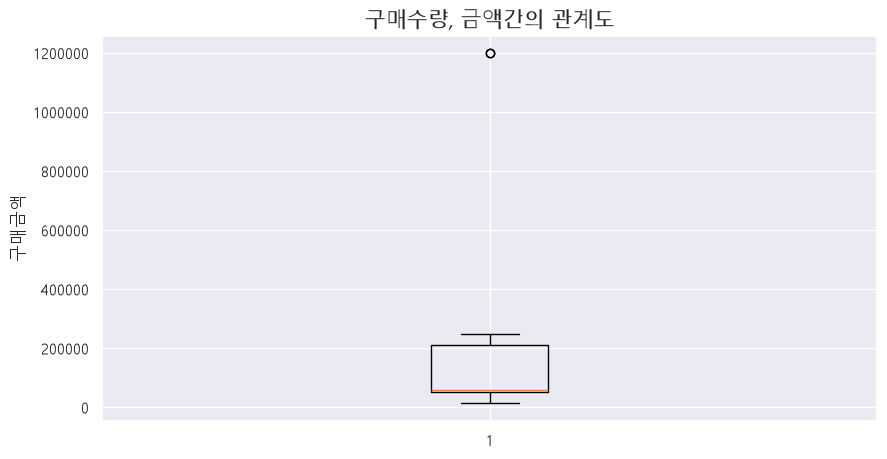

In [48]:
plt.figure(figsize=(10, 5))

plt.boxplot(df['total_price'])
plt.title('구매수량, 금액간의 관계도', fontsize=15)
plt.ylabel('구매금액')

plt.ticklabel_format(style='plain', axis='y')
plt.show()

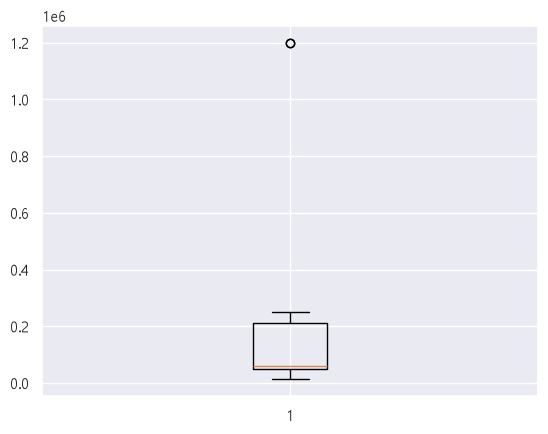

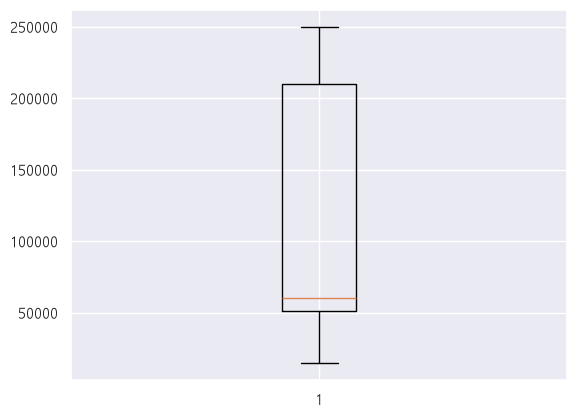

In [53]:
# 1. Outlier 포함
plt.boxplot(df['total_price'])
plt.show()

# 2. Outlier를 화면에서 숨김
plt.boxplot(df['total_price'], showfliers=False)
plt.show()

Line graph Marker 표시

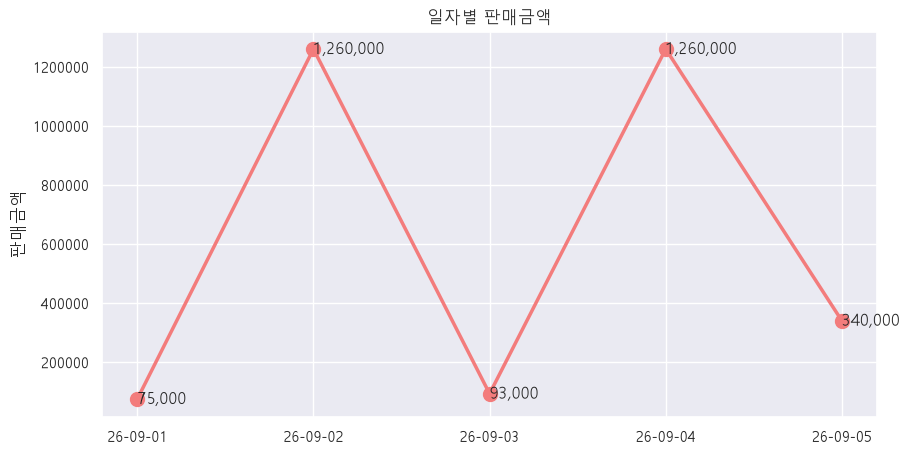

In [67]:
plt.figure(figsize=(10,5))
plt.plot(daily_sales['order_date'], daily_sales['total_price'], 
         marker='o', 
         markersize=10, 
         linewidth=2.5, 
         color= "#F37C7C")

#마커 위치에 실제 데이터 표시
for x, y in zip(daily_sales['order_date'], daily_sales['total_price']):
    plt.text(
        x, y,
        f"{y:,.0f}",  # y값 = 금액
        ha='left',   # 가로축 정렬: left, center, right
        va='center'    # 세로축 정렬: top, center, bottom
    )

plt.title('일자별 판매금액')
plt.ylabel('판매금액')
plt.ticklabel_format(style='plain', axis='y')

#실제 데이터가 있는 위치의 x좌표 레이블 표시
plt.xticks(
    daily_sales['order_date'],
    daily_sales['order_date'].dt.strftime('%y-%m-%d')
)

plt.show()

번외편: PLOTLY 활용

In [60]:
%pip install plotly

Defaulting to user installation because normal site-packages is not writeable
  Using cached plotly-7.1.0-py3-none-any.whl.metadata (8.8 kB)
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   -------- ------------------------------- 2.1/9.7 MB 11.8 MB/s eta 0:00:01
   ---------------------------- ----------- 6.8/9.7 MB 17.7 MB/s eta 0:00:01
   ---------------------------------------- 9.7/9.7 MB 20.5 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.7 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.7 MB 525.1 kB/s eta 0:00:18
   -- ------------------------------------- 0.5/9.7 MB 525.1 kB/s eta 0:00:18
   -- ------------------------------------- 0.5/9.7 MB 525.1 kB/s eta 0:00:18
   -- ------------------------------------- 0.5/9.7 MB 525.1 kB/s eta 0:00:18
   -- ------------------------------------- 0.5/9.7 MB 525.1 kB/s eta 0:00:18
   --- ------------------------------------ 0.8/9.7 MB 363.9 kB/s eta 0:00:25
   --- ------------------------------------ 0.8/9.7 MB 363.9 kB/s eta 0:00:25
   --- ------------------------------------ 0.8/9.7 MB 363.9 kB/s eta 0:00:25
   --- ---------------

In [61]:
import plotly.express as px

In [62]:
fig = px.line(
    daily_sales,
    x='order_date',
    y='total_price',
    markers=True,
    title='일자별 판매금액'
)

fig.update_traces(
    line=dict(width=2.5, color="#BBF066"),
    marker=dict(size=10),
    text=daily_sales['total_price'],
    texttemplate='%{text:,.0f}',
    textposition='middle right'
)

fig.update_layout(
    xaxis_title='날짜',
    yaxis_title='판매금액'
)

fig.show()

SEABORN 
-Matplotlib은 판다스 DF를 바로 사용 못함. Seaborn은 가능
-seaborn은 데이터 프레임 그대로 data 속성에 전달

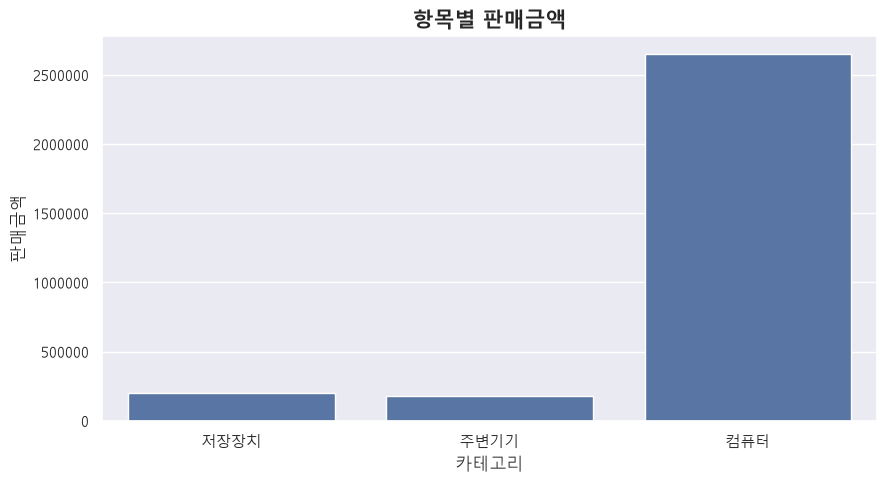

In [63]:
plt.figure(figsize=(10, 5))

# 막대그래프 plt.bar() -> Seaborn barplot으로 변경
sns.barplot(data=cate_sales, x='category', y='total_price')

plt.title('항목별 판매금액', fontsize=15, fontweight='bold')
plt.xlabel('카테고리')
plt.ylabel('판매금액')

plt.ticklabel_format(style='plain', axis='y')  # y축을 판매금액 그대로 출력

plt.show()

Seaborn Heatmap

In [65]:
df[['quantity', 'unit_price', 'total_price']].corr()

,quantity,unit_price,total_price
quantity,1.000000,-0.466431,-0.439778
unit_price,-0.466431,1.000000,0.999447
total_price,-0.439778,0.999447,1.000000


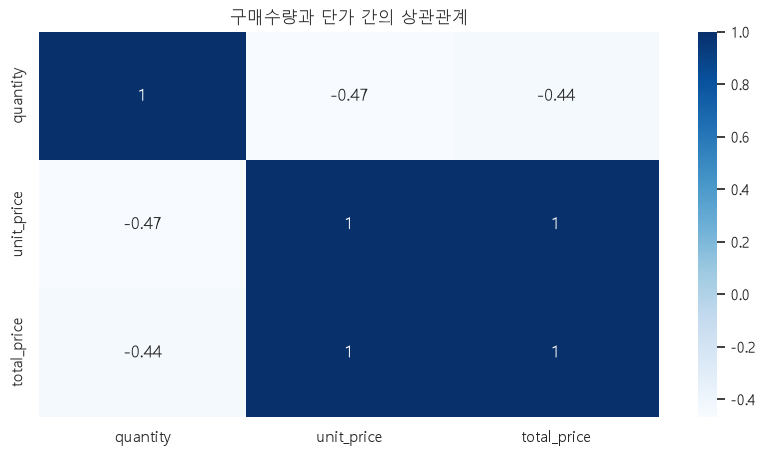

In [66]:
plt.figure(figsize=(10, 5))

# 히트맵
sns.heatmap(data=corr, annot=True, cmap='Blues')

plt.title('구매수량과 단가 간의 상관관계')
plt.show()